# Poisson PINN — Adam comparison

This notebook performs the **six Poisson PINN comparisons considered in the accompanying paper**:

1. **MSE**
2. **Inverse-Dirichlet adaptive weighting**
3. **GradNorm**
4. **NTK-based balancing**
5. **SINOS**
6. **D-SINOS**

The experiment can either be started from scratch or resumed from saved states:

```python
MODE = "fresh"   # start a new experiment
MODE = "resume"  # continue from warm_start_states/
```

In [105]:
import copy
import os
import time

# Parallelization strategy:
#   - repetitions run in separate processes;
#   - the six formulations remain sequential within each repetition;
#   - each worker receives only a fraction of the CPU thread budget to avoid oversubscription.
CPU_COUNT = os.cpu_count() or 1
N_REP_WORKERS = min(5, CPU_COUNT)
THREADS_PER_WORKER = max(1, CPU_COUNT // N_REP_WORKERS)

# Set BLAS/OpenMP limits before importing torch so worker processes inherit them.
os.environ["OMP_NUM_THREADS"] = str(THREADS_PER_WORKER)
os.environ["MKL_NUM_THREADS"] = str(THREADS_PER_WORKER)
os.environ["OPENBLAS_NUM_THREADS"] = str(THREADS_PER_WORKER)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(THREADS_PER_WORKER)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from joblib import Parallel, delayed, parallel_config
from pathlib import Path
from matplotlib.colors import LogNorm

from dd_discretization import DomainDecompositionDiscretization
from utils import make_boundary_hhalf_matrix_torch
from pinns import TanhPINN


In [106]:
# --- Experiment configuration ---

MODE = "resume"  # "fresh" or "resume"

CELLWISE_NEGATIVE_NORM = True

RESULT_DIR = Path("results/poisson_pinn_balancing_adam")
WARM_START_DIR = RESULT_DIR / "warm_start_states"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
WARM_START_DIR.mkdir(parents=True, exist_ok=True)

SEED = 1234
N_REPS = 5
REP_SEEDS = [SEED + rep for rep in range(N_REPS)]

if MODE == "resume":
    manifest_path = WARM_START_DIR / "manifest.pt"

    if manifest_path.exists():
        manifest = torch.load(
            manifest_path,
            map_location="cpu",
            weights_only=False,
        )
        N_REPS = int(manifest["N_REPS"])
        REP_SEEDS = [int(seed) for seed in manifest["REP_SEEDS"]]
        SEED = REP_SEEDS[0]

elif MODE != "fresh":
    raise ValueError("MODE must be either 'fresh' or 'resume'.")

device = torch.device("cpu")
dtype = torch.float64
torch.set_default_dtype(dtype)

N_REP_WORKERS = min(5, CPU_COUNT, N_REPS)
THREADS_PER_WORKER = max(1, CPU_COUNT // N_REP_WORKERS)

np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_num_threads(THREADS_PER_WORKER)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print("MODE:", MODE)
print("RESULT_DIR:", RESULT_DIR)
print("WARM_START_DIR:", WARM_START_DIR)
print("N_REPS:", N_REPS)
print("seeds:", REP_SEEDS)
print("device:", device)
print("dtype:", dtype)
print("parallel repetition workers:", N_REP_WORKERS)
print("CPU threads per worker:", THREADS_PER_WORKER)


MODE: resume
RESULT_DIR: results/poisson_pinn_balancing_adam
WARM_START_DIR: results/poisson_pinn_balancing_adam/warm_start_states
N_REPS: 5
seeds: [1234, 1235, 1236, 1237, 1238]
device: cpu
dtype: torch.float64
parallel repetition workers: 5
CPU threads per worker: 2


## Problem

### Asymmetric nonzero-boundary test function

To test a less symmetric setting with nonzero boundary values, we use the manufactured solution
$$
u(x,y)
=
\alpha_{\exp} e^{a x + b y}
+
\alpha_{\mathrm{osc}} \sin(k_x x + k_y y)
+
\alpha_{\mathrm{poly}} xy
+
\ell_x x
+
\ell_y y ,
$$
with parameters
$$
\alpha_{\exp}=0.25,\qquad
\alpha_{\mathrm{osc}}=0.75,\qquad
\alpha_{\mathrm{poly}}=0.5,
$$
$$
\ell_x=0.10,\qquad
\ell_y=-0.20,
$$
and
$$
a=2.0,\qquad b=-0.75,\qquad k_x=8.0,\qquad k_y=2.0.
$$

This choice combines an anisotropic exponential component, an oscillatory component with different frequencies in the two coordinate directions, a mixed polynomial term, and a linear contribution. In particular, the solution is not symmetric with respect to the coordinate axes and does not vanish on the boundary.

For the Poisson equation
$$
\Delta u = f
$$
on the computational domain, the corresponding right-hand side is
$$
f(x,y)
=
\alpha_{\exp}(a^2+b^2)e^{a x+b y}
-
\alpha_{\mathrm{osc}}(k_x^2+k_y^2)\sin(k_x x+k_y y).
$$
The mixed polynomial term $xy$ and the linear terms have zero Laplacian and therefore do not contribute to $f$.

In [107]:
EXP_AMP = 0.25
OSC_AMP = 0.75
POLY_AMP = 0.5
LIN_X = 0.10
LIN_Y = -0.20

a = 2.0
b = -0.75

kx = 8.0
ky = 2.0


def exact_u(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    exp_part = EXP_AMP * torch.exp(a * x1 + b * x2)
    osc_part = OSC_AMP * torch.sin(kx * x1 + ky * x2)
    poly_part = POLY_AMP * x1 * x2
    lin_part = LIN_X * x1 + LIN_Y * x2

    return exp_part + osc_part + poly_part + lin_part


def rhs_f(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    exp_part_lap = (
        EXP_AMP
        * (a**2 + b**2)
        * torch.exp(a * x1 + b * x2)
    )

    osc_part_lap = (
        -OSC_AMP
        * (kx**2 + ky**2)
        * torch.sin(kx * x1 + ky * x2)
    )

    # Laplacian of x*y and linear terms is zero.
    return exp_part_lap + osc_part_lap

In [108]:
# --- Discretization ---

# Polynomial degrees for the Gauss-Legendre tensor grid
nx, ny = 10, 10

# Number of cells in x/y direction
rx, ry = 5, 5

disc = DomainDecompositionDiscretization(
    polynomial_degrees=(nx, ny),
    cells_per_dim=(rx, ry),
    domain=[(-1.0, 1.0), (-1.0, 1.0)],
)
disc.init_boundary_quadrature()

pde_points = disc.points
assert pde_points.shape == (disc.N, 2)

X_pde = torch.as_tensor(pde_points, device=device, dtype=dtype)
X_bc = torch.as_tensor(disc.X_bc, device=device, dtype=dtype)
u_bc = exact_u(X_bc).detach()
f_pde = rhs_f(X_pde).detach()  # fixed forcing; no need to differentiate through it

W_bc = torch.as_tensor(disc.W_bc, device=device, dtype=dtype)
W = torch.as_tensor(disc.W, device=device, dtype=dtype)
Hmat_pinv = torch.as_tensor(disc.Hmat_pinv, device=device, dtype=dtype)
Hmat_pinv_s = torch.as_tensor(disc.Hmat_s_pinv, device=device, dtype=dtype)

W_bc_half = make_boundary_hhalf_matrix_torch(
    X_bc,
    W_bc,
    boundary_dim=1,
).to(device=device, dtype=dtype)

N_CELLS = rx * ry
N_LOCAL = (nx + 1) * (ny + 1)
assert disc.N == N_CELLS * N_LOCAL

if CELLWISE_NEGATIVE_NORM:
    # Apply the discrete negative-order operator independently on each cell.
    Q_sinos = torch.stack([
        W[cell * N_LOCAL:(cell + 1) * N_LOCAL,
          cell * N_LOCAL:(cell + 1) * N_LOCAL]
        @ Hmat_pinv[cell * N_LOCAL:(cell + 1) * N_LOCAL,
                    cell * N_LOCAL:(cell + 1) * N_LOCAL]
        for cell in range(N_CELLS)
    ])

    Q_dsinos = torch.stack([
        W[cell * N_LOCAL:(cell + 1) * N_LOCAL,
          cell * N_LOCAL:(cell + 1) * N_LOCAL]
        @ Hmat_pinv_s[cell * N_LOCAL:(cell + 1) * N_LOCAL,
                      cell * N_LOCAL:(cell + 1) * N_LOCAL]
        for cell in range(N_CELLS)
    ])
else:
    # Original global quadratic forms.
    Q_sinos = W @ Hmat_pinv
    Q_dsinos = W @ Hmat_pinv_s

# These tensors define the single fixed collocation grid used by every seed and every method.
DATA = {
    "X_pde": X_pde,
    "X_bc": X_bc,
    "u_bc": u_bc,
    "f_pde": f_pde,
    "Q_sinos": Q_sinos,
    "Q_dsinos": Q_dsinos,
    "W_bc_half": W_bc_half,
    "cellwise_negative_norm": CELLWISE_NEGATIVE_NORM,
    "n_cells": N_CELLS,
    "n_local": N_LOCAL,
}

print("PDE points:", X_pde.shape[0])
print("boundary points:", X_bc.shape[0])
print(
    "SINOS / D-SINOS PDE application:",
    "cell-wise" if CELLWISE_NEGATIVE_NORM else "global",
)


# No collocation points are resampled during training.
FIXED_PDE_POINTS = X_pde.detach().clone()
FIXED_BC_POINTS = X_bc.detach().clone()


PDE points: 3025
boundary points: 220
SINOS / D-SINOS PDE application: cell-wise


In [109]:
# --- PINN ---

def make_model(initialize=True):
    return TanhPINN([2, 50, 50, 50, 50, 50, 1]).to(
        device=device,
        dtype=dtype,
    )

In [110]:
# --- PDE residual ---

def poisson_residual(model, x, f):
    x_req = x.detach().requires_grad_(True)
    u = model(x_req)

    grad_u = torch.autograd.grad(
        u,
        x_req,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    u_xx = torch.autograd.grad(
        u_x,
        x_req,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0][:, 0:1]

    u_yy = torch.autograd.grad(
        u_y,
        x_req,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True,
    )[0][:, 1:2]

    return u_xx + u_yy - f


In [111]:
# --- Losses ---

def _quadratic_form(r, Q):
    r = r.reshape(-1)
    return torch.dot(r, torch.mv(Q, r))


def _cellwise_quadratic_form(r, Q_cells, n_cells, n_local):
    r_cells = r.reshape(n_cells, n_local)
    return torch.einsum("ei,eij,ej->", r_cells, Q_cells, r_cells)


def compute_loss_components(model, data, loss_kind):
    """Return residual vectors and unweighted PDE / boundary loss components."""
    r_pde = poisson_residual(model, data["X_pde"], data["f_pde"])
    r_bc = model(data["X_bc"]) - data["u_bc"]

    if loss_kind == "mse":
        pde_loss = torch.mean(r_pde.square())
        bc_loss = torch.mean(r_bc.square())

    elif loss_kind == "sinos":
        if data["cellwise_negative_norm"]:
            pde_loss = _cellwise_quadratic_form(
                r_pde,
                data["Q_sinos"],
                data["n_cells"],
                data["n_local"],
            )
        else:
            pde_loss = _quadratic_form(r_pde, data["Q_sinos"])
        bc_loss = _quadratic_form(r_bc, data["W_bc_half"])

    elif loss_kind == "dsinos":
        if data["cellwise_negative_norm"]:
            pde_loss = _cellwise_quadratic_form(
                r_pde,
                data["Q_dsinos"],
                data["n_cells"],
                data["n_local"],
            )
        else:
            pde_loss = _quadratic_form(r_pde, data["Q_dsinos"])
        bc_loss = _quadratic_form(r_bc, data["W_bc_half"])

    else:
        raise ValueError(f"unknown loss_kind={loss_kind!r}")

    return r_pde, r_bc, pde_loss, bc_loss


In [112]:
# --- Evaluation --- 

def make_eval_grid(n_eval=201):
    grid = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype)
    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))
    with torch.no_grad():
        u_true = exact_u(XY).reshape(n_eval, n_eval)
    return XY, u_true


def evaluate_solution(model=None, n_eval=201):
    XY, u_true = make_eval_grid(n_eval=n_eval)

    with torch.no_grad():
        if model is None:
            return None

        u_pred = model(XY).reshape(n_eval, n_eval)
        error = u_true - u_pred
        abs_error = torch.abs(error)

        mse = torch.mean(error.square())
        rmse = torch.sqrt(mse)
        max_error = torch.max(abs_error)

        return {
            "prediction": u_pred.detach().cpu().numpy(),
            "error": error.detach().cpu().numpy(),
            "mse": float(mse.detach().cpu()),
            "rmse": float(rmse.detach().cpu()),
            "max_error": float(max_error.detach().cpu()),
        }


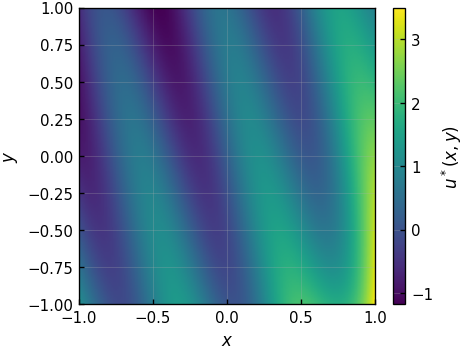

In [113]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Ground-truth solution ---

_, u_true = make_eval_grid(n_eval=201)
u_true = u_true.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(4, 3.5))

im = ax.imshow(
    u_true.T,
    extent=[-1, 1, -1, 1],
    origin="lower",
    aspect="equal",
)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.15)
fig.colorbar(im, cax=cax, label=r"$u^*(x,y)$")

fig.tight_layout()

fig.savefig(
    RESULT_DIR / "ground_truth.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()

## Balancing methods

Only the **MSE** loss is combined with the three balancing schemes. SINOS and D-SINOS are kept as their own residual geometries.

### Inverse-Dirichlet weighting

For the loss components $L_k$, inverse-Dirichlet weighting uses the variance of the back-propagated task gradients,

$$
\widehat{\lambda}_k
=
\frac{
    \max_t \operatorname{Var}(\nabla_\theta L_t)
}{
    \operatorname{Var}(\nabla_\theta L_k)
},
$$

followed by the moving-average update

$$
\lambda_k
\leftarrow
\alpha \lambda_k
+
(1-\alpha)\widehat{\lambda}_k .
$$

Following the original method, the weights are initialized to one and we use
$\alpha=0.5$.

### GradNorm

For losses $L_i$ with adaptive weights $w_i$, GradNorm measures the weighted gradient norms

$$
G_i
=
\left\|
\nabla_W (w_i L_i)
\right\|_2
$$

with respect to the last shared network layer $W$. These are compared with the targets

$$
\overline{G}\,r_i^\alpha,
$$

where $r_i$ denotes the relative inverse training rate of task $i$.
The weights are updated by minimizing the corresponding $L^1$ GradNorm objective and are subsequently renormalized such that

$$
\sum_i w_i = 2 .
$$

We use $\alpha=1.5$, as in the main experiments of the original GradNorm paper.

### NTK balancing

For each residual vector $r_i$, let

$$
J_i
=
\frac{\partial r_i}{\partial\theta},
\qquad
K_i
=
J_i J_i^\top .
$$

The NTK balancing strategy assigns

$$
\lambda_i
=
\frac{\operatorname{Tr}(K)}
     {\operatorname{Tr}(K_i)},
$$

where

$$
\operatorname{Tr}(K)
=
\sum_i \operatorname{Tr}(K_i).
$$

Since explicitly forming the Jacobians is expensive, the notebook estimates the traces using Hutchinson probes,

$$
\operatorname{Tr}(J_iJ_i^\top)
=
\mathbb E_z
\left[
    \|J_i^\top z\|_2^2
\right],
\qquad
z_k\in\{-1,+1\}.
$$

This provides a stochastic estimate of the original NTK trace-balancing criterion without explicitly materializing the full Jacobian.

In [114]:
# --- Helper functions for balancing methods ---

EPS = 1e-30


def _all_trainable_parameters(model):
    return tuple(p for p in model.parameters() if p.requires_grad)


def _linear_parameters(model):
    params = []
    for module in model.modules():
        if isinstance(module, nn.Linear):
            params.extend(p for p in module.parameters() if p.requires_grad)
    return tuple(params) if params else _all_trainable_parameters(model)


def _last_shared_parameters(model):
    linears = [module for module in model.modules() if isinstance(module, nn.Linear)]
    if linears:
        return tuple(p for p in linears[-1].parameters() if p.requires_grad)
    params = _all_trainable_parameters(model)
    return params[-2:] if len(params) >= 2 else params


def _grad_std(loss, params):
    """Standard deviation of all scalar parameter gradients without concatenating them."""
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )

    n = 0
    s1 = loss.new_zeros(())
    s2 = loss.new_zeros(())

    for g in grads:
        if g is None:
            continue
        gd = g.detach()
        n += gd.numel()
        s1 = s1 + gd.sum()
        s2 = s2 + gd.square().sum()

    if n <= 1:
        return loss.new_zeros(())

    mean = s1 / n
    # torch.std uses the sample correction by default; match that convention closely.
    var = (s2 - n * mean.square()) / (n - 1)
    return torch.sqrt(torch.clamp(var, min=0.0))


def _grad_l2_norm(loss, params):
    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=True,
        create_graph=False,
        allow_unused=True,
    )
    sq = loss.new_zeros(())
    for g in grads:
        if g is not None:
            sq = sq + g.detach().square().sum()
    return torch.sqrt(sq + EPS)


def _hutchinson_ntk_trace_per_output(residual, params, generator, n_probes=1):
    """Estimate tr(J J^T) / n with VJPs; never materializes the Jacobian J."""
    r = residual.reshape(-1)
    n = r.numel()
    estimate = r.new_zeros(())

    for _ in range(n_probes):
        # normalized Rademacher vector: E ||J^T z||^2 = tr(JJ^T) / n
        z = torch.randint(
            0,
            2,
            (n,),
            generator=generator,
            device=r.device,
            dtype=torch.int64,
        ).to(r.dtype)
        z = (2.0 * z - 1.0) / np.sqrt(n)

        vjp = torch.autograd.grad(
            r,
            params,
            grad_outputs=z,
            retain_graph=True,
            create_graph=False,
            allow_unused=True,
        )

        sq = r.new_zeros(())
        for g in vjp:
            if g is not None:
                sq = sq + g.detach().square().sum()
        estimate = estimate + sq

    return estimate / n_probes


In [115]:
# --- Update rules for balancing methods ---

def update_inverse_dirichlet(model, pde_loss, bc_loss, state):
    """Inverse-Dirichlet update used in this experiment."""
    params = _linear_parameters(model)

    std_pde = _grad_std(pde_loss, params)
    std_bc = _grad_std(bc_loss, params)
    lambda_hat = std_pde / (std_bc + EPS)

    old = state["weights"][1]
    new = (1.0 - ID_EMA_NEW) * old + ID_EMA_NEW * lambda_hat
    state["weights"] = torch.stack((new.new_tensor(1.0), new.detach()))


def update_gradnorm(model, pde_loss, bc_loss, state):
    """GradNorm update used in this experiment."""
    selected_params = _last_shared_parameters(model)

    base_norms = torch.stack((
        _grad_l2_norm(pde_loss, selected_params),
        _grad_l2_norm(bc_loss, selected_params),
    )).detach()

    losses_detached = torch.stack((pde_loss.detach(), bc_loss.detach()))

    if state["initial_losses"] is None:
        state["initial_losses"] = losses_detached.clamp_min(EPS)

    w = state["weight_param"]
    actual = w * base_norms

    loss_ratio = losses_detached / state["initial_losses"]
    relative_rate = loss_ratio / loss_ratio.mean().clamp_min(EPS)
    target = (
        actual.mean().detach()
        * relative_rate.pow(GRADNORM_ALPHA)
    ).detach()

    gradnorm_objective = torch.abs(actual - target).sum()
    grad_w = torch.autograd.grad(
        gradnorm_objective,
        w,
        retain_graph=False,
    )[0]

    opt_w = state["weight_optimizer"]
    opt_w.zero_grad(set_to_none=True)
    w.grad = grad_w
    opt_w.step()

    with torch.no_grad():
        w.clamp_(min=1e-12)
        w.mul_(2.0 / w.sum().clamp_min(EPS))
        state["weights"] = w.detach().clone()


def update_ntk(model, r_pde, r_bc, state):
    """NTK trace-balancing update used in this experiment."""
    params = _all_trainable_parameters(model)

    t_pde = _hutchinson_ntk_trace_per_output(
        r_pde,
        params,
        state["rng"],
        n_probes=NTK_PROBES,
    )
    t_bc = _hutchinson_ntk_trace_per_output(
        r_bc,
        params,
        state["rng"],
        n_probes=NTK_PROBES,
    )

    traces = torch.stack((t_pde, t_bc)).clamp_min(EPS)
    inv = traces.reciprocal()
    raw = 2.0 * inv / inv.sum()

    old = state["weights"]
    smoothed = NTK_EMA_OLD * old + (1.0 - NTK_EMA_OLD) * raw
    state["weights"] = (2.0 * smoothed / smoothed.sum()).detach()


## Adam training

The six formulations use the same Adam training procedure.

For every formulation, the learning rate is selected from the dense candidate set by a short **8-step probe**. Each candidate starts from the **same base initialization**. The probe minimizes the unweighted raw residual sum
$$
L_{\mathrm{probe}}=L_{\mathrm{PDE}}+L_{\mathrm{BC}},
$$
and chooses the candidate with the smallest finite ratio
$$
L_{\mathrm{probe}}^{(8)}/L_{\mathrm{probe}}^{(0)}.
$$

For the three MSE balancing methods (ID, GradNorm, NTK), the balancing rule is deliberately **not applied during the probe**. SINOS and D-SINOS are probed using their actual residual geometries. All probe steps are discarded, and the selected formulation is reset to the original base initialization before the 25,000-step Adam run starts.

In `MODE = "resume"`, the model, selected learning rate, Adam optimizer state, balancing state, and history are restored from `warm_start_states/`.


In [116]:
# --- Adam configuration ---

MAX_STEPS = 30_000
EVAL_N = 201

LR_PROBE_STEPS = 8
LR_CANDIDATES = (
    1e-5,
    3e-5,
    1e-4,
    2e-4,
    3e-4,
    5e-4,
    7e-4,
    1e-3,
    2e-3,
    3e-3,
    5e-3,
)

ID_EMA_NEW = 0.5
ID_UPDATE_EVERY = 5

GRADNORM_ALPHA = 1.5
GRADNORM_WEIGHT_LR = 0.025
GRADNORM_UPDATE_EVERY = 1

NTK_UPDATE_EVERY = 10
NTK_PROBES = 1
NTK_EMA_OLD = 0.0

RUN_CONFIGS = [
    {"method": "MSE", "loss_kind": "mse", "balancer": None, "balance_every": None},
    {"method": "ID", "loss_kind": "mse", "balancer": "inverse_dirichlet", "balance_every": ID_UPDATE_EVERY},
    {"method": "GradNorm", "loss_kind": "mse", "balancer": "gradnorm", "balance_every": GRADNORM_UPDATE_EVERY},
    {"method": "NTK", "loss_kind": "mse", "balancer": "ntk", "balance_every": NTK_UPDATE_EVERY},
    {"method": "SINOS", "loss_kind": "sinos", "balancer": None, "balance_every": None},
    {"method": "D-SINOS", "loss_kind": "dsinos", "balancer": None, "balance_every": None},
]


def should_record_step(k):
    if k == 0:
        return True
    if k <= 100:
        return True

    decade = 10 ** int(np.floor(np.log10(k)))
    stride = max(1, decade // 10)
    return (k % stride) == 0


PRINT_STEPS = {1} | {round(k * MAX_STEPS / 10) for k in range(1, 11)}

print("training runs:", N_REPS * len(RUN_CONFIGS))
print("Adam-step target:", MAX_STEPS)
print("LR probe steps per candidate:", LR_PROBE_STEPS)
print("LR candidates:", LR_CANDIDATES)
print("discarded probe steps per method:", len(LR_CANDIDATES) * LR_PROBE_STEPS)
print("evaluation grid:", f"{EVAL_N} x {EVAL_N}")
print("workers:", N_REP_WORKERS, "| threads per worker:", THREADS_PER_WORKER)


training runs: 30
Adam-step target: 30000
LR probe steps per candidate: 8
LR candidates: (1e-05, 3e-05, 0.0001, 0.0002, 0.0003, 0.0005, 0.0007, 0.001, 0.002, 0.003, 0.005)
discarded probe steps per method: 88
evaluation grid: 201 x 201
workers: 5 | threads per worker: 2


In [117]:
# --- Diagnostics and balancing-state helpers ---

def _diagnostic_grid(n_eval):
    grid = torch.linspace(-1.0, 1.0, n_eval, dtype=torch.float64, device="cpu")
    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))
    with torch.no_grad():
        truth = exact_u(XY).reshape(-1)
    return XY, truth


def _diagnostic_metrics(model, XY, truth):
    with torch.no_grad():
        pred = model(XY).reshape(-1)
        err = truth - pred
        mse = torch.mean(err.square())
        return {
            "mse": float(mse),
            "rmse": float(torch.sqrt(mse)),
            "max_error": float(torch.max(torch.abs(err))),
        }


def _init_balancer(model, config, seed):
    state = {
        "weights": torch.ones(2, dtype=dtype, device=device),
        "initial_losses": None,
        "rng": torch.Generator(device="cpu").manual_seed(seed),
    }

    if config["balancer"] == "gradnorm":
        weight_param = nn.Parameter(torch.ones(2, dtype=dtype, device=device))
        state["weight_param"] = weight_param
        state["weight_optimizer"] = torch.optim.Adam(
            [weight_param],
            lr=GRADNORM_WEIGHT_LR,
        )

    return state


def _update_balancer(model, config, state, r_pde, r_bc, pde_loss, bc_loss):
    balancer = config["balancer"]

    if balancer is None:
        return

    if balancer == "inverse_dirichlet":
        update_inverse_dirichlet(model, pde_loss, bc_loss, state)
        return

    if balancer == "gradnorm":
        update_gradnorm(model, pde_loss, bc_loss, state)
        return

    if balancer == "ntk":
        update_ntk(model, r_pde, r_bc, state)
        return

    raise ValueError(f"unknown balancer={balancer!r}")


def _serialize_balancer_state(state, config):
    payload = {
        "weights": state["weights"].detach().cpu().clone(),
        "initial_losses": (
            None
            if state["initial_losses"] is None
            else state["initial_losses"].detach().cpu().clone()
        ),
        "rng_state": state["rng"].get_state(),
    }

    if config["balancer"] == "gradnorm":
        payload["weight_param"] = state["weight_param"].detach().cpu().clone()
        payload["weight_optimizer_state"] = copy.deepcopy(
            state["weight_optimizer"].state_dict()
        )

    return payload


def _restore_balancer_state(model, config, seed, saved_payload):
    state = _init_balancer(model, config, seed)

    if saved_payload is None:
        return state

    state["weights"] = saved_payload["weights"].to(device=device, dtype=dtype)

    if saved_payload.get("initial_losses") is not None:
        state["initial_losses"] = saved_payload["initial_losses"].to(
            device=device,
            dtype=dtype,
        )

    if saved_payload.get("rng_state") is not None:
        state["rng"].set_state(saved_payload["rng_state"])

    if config["balancer"] == "gradnorm":
        with torch.no_grad():
            state["weight_param"].copy_(
                saved_payload["weight_param"].to(device=device, dtype=dtype)
            )
        state["weights"] = state["weight_param"].detach().clone()

        if "weight_optimizer_state" in saved_payload:
            state["weight_optimizer"].load_state_dict(
                saved_payload["weight_optimizer_state"]
            )

    return state


In [118]:
# --- Dense learning-rate probe ---

def _raw_probe_loss(model, config, data):
    _, _, pde_loss, bc_loss = compute_loss_components(
        model,
        data,
        config["loss_kind"],
    )
    return pde_loss + bc_loss


def select_learning_rate(config, base_state, data):
    records = []

    for lr in LR_CANDIDATES:
        model = make_model(initialize=False)
        model.load_state_dict(copy.deepcopy(base_state))
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        initial_loss = _raw_probe_loss(model, config, data)
        initial_value = float(initial_loss.detach())
        finite = np.isfinite(initial_value) and initial_value > 0.0

        if finite:
            for _ in range(LR_PROBE_STEPS):
                optimizer.zero_grad(set_to_none=True)
                loss = _raw_probe_loss(model, config, data)

                if not torch.isfinite(loss):
                    finite = False
                    break

                loss.backward()
                optimizer.step()

        if finite:
            final_loss = _raw_probe_loss(model, config, data)
            final_value = float(final_loss.detach())
            finite = np.isfinite(final_value)
        else:
            final_value = np.inf

        ratio = (
            final_value / initial_value
            if finite and initial_value > 0.0
            else np.inf
        )

        records.append({
            "method": config["method"],
            "loss_kind": config["loss_kind"],
            "lr": float(lr),
            "probe_steps": int(LR_PROBE_STEPS),
            "initial_loss": initial_value,
            "final_loss": final_value,
            "loss_ratio": ratio,
            "finite": bool(finite),
        })

        del optimizer, model

    probe_df = pd.DataFrame(records)
    finite_df = probe_df[np.isfinite(probe_df["loss_ratio"])]

    if finite_df.empty:
        raise RuntimeError(
            f"No finite Adam LR probe succeeded for {config['method']}."
        )

    best_idx = finite_df["loss_ratio"].idxmin()
    selected_lr = float(probe_df.loc[best_idx, "lr"])

    print(
        f"{config['method']:16s} | selected Adam LR = {selected_lr:.1e} | "
        f"8-step ratio = {probe_df.loc[best_idx, 'loss_ratio']:.3e}"
    )

    return selected_lr, probe_df


In [119]:
# --- Warm-state helpers ---

def _warm_state_slug(method):
    return method.lower().replace("+", "plus").replace("-", "_").replace(" ", "_")


def warm_state_path(seed, method):
    return WARM_START_DIR / f"seed_{seed}__{_warm_state_slug(method)}.pt"


def load_warm_state(seed, method):
    path = warm_state_path(seed, method)
    if not path.exists():
        raise FileNotFoundError(f"Missing warm-start state: {path}")

    saved = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    if int(saved["seed"]) != int(seed):
        raise ValueError(f"Seed mismatch in {path}: {saved['seed']} != {seed}")
    if saved["method"] != method:
        raise ValueError(
            f"Method mismatch in {path}: {saved['method']!r} != {method!r}"
        )

    return saved


def _save_adam_state(item):
    path = warm_state_path(item["seed"], item["method"])
    tmp_path = path.with_suffix(path.suffix + ".tmp")

    payload = {
        "format": "adam_warm_start_v1",
        "seed": int(item["seed"]),
        "rep": int(item["rep"]),
        "method": item["method"],
        "config": copy.deepcopy(item["config"]),
        "state_dict": {
            key: value.detach().cpu().clone()
            for key, value in item["state_dict"].items()
        },
        "optimizer_state_dict": copy.deepcopy(item["optimizer_state_dict"]),
        "balancer_state": copy.deepcopy(item["balancer_state"]),
        "selected_lr": float(item["selected_lr"]),
        "steps": int(item["steps"]),
        "elapsed_s": float(item["elapsed_s"]),
        "final_weights": tuple(float(x) for x in item["final_weights"]),
        "final_losses": copy.deepcopy(item["final_losses"]),
        "history_records": item["history"].to_dict(orient="records"),
        "lr_probe_records": item["lr_probe"].to_dict(orient="records"),
    }

    torch.save(payload, tmp_path)
    os.replace(tmp_path, path)


In [120]:
# --- One Adam run ---

def run_one_method(config, base_state, data, seed, rep, saved=None):
    model = make_model(initialize=False)

    if saved is None:
        selected_lr, lr_probe = select_learning_rate(
            config,
            base_state,
            data,
        )

        model.load_state_dict(copy.deepcopy(base_state))
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=selected_lr,
        )

        balance_state = _init_balancer(
            model,
            config,
            seed + 100_000,
        )

        history = []
        completed_steps = 0
        elapsed_offset = 0.0

    else:
        selected_lr = float(saved["selected_lr"])
        lr_probe = pd.DataFrame(saved.get("lr_probe_records", []))

        model.load_state_dict(saved["state_dict"])
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=selected_lr,
        )
        optimizer.load_state_dict(saved["optimizer_state_dict"])

        balance_state = _restore_balancer_state(
            model,
            config,
            seed + 100_000,
            saved.get("balancer_state"),
        )

        history = copy.deepcopy(saved.get("history_records", []))
        completed_steps = int(saved["steps"])
        elapsed_offset = float(saved.get("elapsed_s", 0.0))

    eval_X, eval_truth = _diagnostic_grid(EVAL_N)
    start = time.perf_counter()

    def elapsed_total():
        return elapsed_offset + (time.perf_counter() - start)

    def append_history_row(step):
        _, _, pde_loss, bc_loss = compute_loss_components(
            model,
            data,
            config["loss_kind"],
        )
        weights = balance_state["weights"].detach()
        total_loss = weights[0] * pde_loss + weights[1] * bc_loss
        metrics = _diagnostic_metrics(model, eval_X, eval_truth)

        row = {
            "rep": rep,
            "seed": seed,
            "method": config["method"],
            "step": int(step),
            "adam_step": int(step),
            "selected_lr": float(selected_lr),
            "total_loss": float(total_loss.detach()),
            "pde_loss": float(pde_loss.detach()),
            "bc_loss": float(bc_loss.detach()),
            "pde_weight": float(weights[0]),
            "bc_weight": float(weights[1]),
            **metrics,
            "elapsed_s": elapsed_total(),
        }
        history.append(row)

        if step in PRINT_STEPS:
            print(
                f"rep {rep+1:02d}/{N_REPS} | {config['method']:16s} | "
                f"Adam {step:06d}/{MAX_STEPS} | lr {selected_lr:.1e} | "
                f"rmse {row['rmse']:.3e} | max {row['max_error']:.3e}"
            )

    if saved is None:
        append_history_row(0)

    if completed_steps >= MAX_STEPS:
        print(
            f"seed {seed} | {config['method']}: already at "
            f"{completed_steps} Adam steps >= target {MAX_STEPS}."
        )
    else:
        for step in range(completed_steps + 1, MAX_STEPS + 1):
            optimizer.zero_grad(set_to_none=True)

            r_pde, r_bc, pde_loss, bc_loss = compute_loss_components(
                model,
                data,
                config["loss_kind"],
            )

            if (
                config["balancer"] is not None
                and (step - 1) % config["balance_every"] == 0
            ):
                _update_balancer(
                    model,
                    config,
                    balance_state,
                    r_pde,
                    r_bc,
                    pde_loss,
                    bc_loss,
                )

            weights = balance_state["weights"].detach()
            total_loss = weights[0] * pde_loss + weights[1] * bc_loss
            total_loss.backward()
            optimizer.step()

            completed_steps = step

            if should_record_step(step):
                append_history_row(step)

    elapsed_s = elapsed_total()

    _, _, pde_final, bc_final = compute_loss_components(
        model,
        data,
        config["loss_kind"],
    )
    weights_final = balance_state["weights"].detach()
    total_final = weights_final[0] * pde_final + weights_final[1] * bc_final

    result = {
        "rep": rep,
        "seed": seed,
        "method": config["method"],
        "config": copy.deepcopy(config),
        "state_dict": {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        },
        "optimizer_state_dict": copy.deepcopy(optimizer.state_dict()),
        "balancer_state": _serialize_balancer_state(balance_state, config),
        "selected_lr": selected_lr,
        "history": pd.DataFrame(history),
        "lr_probe": lr_probe,
        "elapsed_s": elapsed_s,
        "steps": completed_steps,
        "step_budget": MAX_STEPS,
        "final_weights": tuple(float(x) for x in balance_state["weights"]),
        "final_losses": {
            "total_loss": float(total_final.detach()),
            "pde_loss": float(pde_final.detach()),
            "bc_loss": float(bc_final.detach()),
        },
    }

    _save_adam_state(result)
    return result


In [121]:
# --- Run repetitions ---

def run_one_repetition(rep, rep_seed):
    torch.set_num_threads(THREADS_PER_WORKER)
    np.random.seed(rep_seed)
    torch.manual_seed(rep_seed)

    base_model = make_model(initialize=True)
    base_state = copy.deepcopy(base_model.state_dict())
    del base_model

    print("=" * 80)
    print(
        f"{MODE.upper()} {rep + 1:02d}/{N_REPS} | seed = {rep_seed} | "
        f"worker threads = {torch.get_num_threads()}"
    )
    print("=" * 80)

    rep_results = []

    for config in RUN_CONFIGS:
        saved = None

        if MODE == "resume":
            path = warm_state_path(rep_seed, config["method"])

            if path.exists():
                saved = load_warm_state(rep_seed, config["method"])
                print(
                    f"rep {rep + 1:02d}/{N_REPS} | "
                    f"{config['method']:16s} | loading saved state "
                    f"at Adam step {saved['steps']}"
                )
            else:
                print(
                    f"rep {rep + 1:02d}/{N_REPS} | "
                    f"{config['method']:16s} | no saved state -> starting fresh"
                )

        result = run_one_method(
            config=config,
            base_state=base_state,
            data=DATA,
            seed=rep_seed,
            rep=rep,
            saved=saved,
        )
        rep_results.append(result)

    return rep_results


print("MODE:", MODE)
print(
    f"Running {N_REPS} repetitions × {len(RUN_CONFIGS)} formulations "
    f"= {N_REPS * len(RUN_CONFIGS)} runs"
)
print("Seeds:", REP_SEEDS)
print("Warm-state directory:", WARM_START_DIR)
print("Adam-step target:", MAX_STEPS)
print(
    f"Parallelization: {N_REP_WORKERS} repetition workers; "
    f"{THREADS_PER_WORKER} CPU threads per worker."
)
print("The six formulations remain sequential within each repetition.\n")

with parallel_config(
    backend="loky",
    n_jobs=N_REP_WORKERS,
    inner_max_num_threads=THREADS_PER_WORKER,
):
    nested_results = Parallel()(
        delayed(run_one_repetition)(rep, rep_seed)
        for rep, rep_seed in enumerate(REP_SEEDS)
    )

all_results = [
    item
    for rep_results in nested_results
    for item in rep_results
]

results = {
    (item["rep"], item["method"]): item
    for item in all_results
}

hist = pd.concat(
    [item["history"] for item in all_results],
    ignore_index=True,
)
hist = hist.sort_values(
    ["rep", "method", "adam_step"]
).reset_index(drop=True)

hist.to_csv(
    RESULT_DIR / "history_all_seeds.csv",
    index=False,
)

lr_probe = pd.concat(
    [item["lr_probe"] for item in all_results],
    ignore_index=True,
)
lr_probe.to_csv(
    RESULT_DIR / "adam_lr_probe.csv",
    index=False,
)

selected_lrs = pd.DataFrame(
    [
        {
            "rep": item["rep"],
            "seed": item["seed"],
            "method": item["method"],
            "selected_lr": item["selected_lr"],
        }
        for item in all_results
    ]
)
selected_lrs.to_csv(
    RESULT_DIR / "selected_adam_learning_rates.csv",
    index=False,
)

manifest = {
    "format": "adam_warm_start_manifest_v1",
    "N_REPS": int(N_REPS),
    "REP_SEEDS": [int(seed) for seed in REP_SEEDS],
    "methods": [config["method"] for config in RUN_CONFIGS],
    "MAX_STEPS": int(MAX_STEPS),
    "LR_PROBE_STEPS": int(LR_PROBE_STEPS),
    "LR_CANDIDATES": [float(lr) for lr in LR_CANDIDATES],
    "saved_files": [
        warm_state_path(item["seed"], item["method"]).name
        for item in all_results
    ],
    "note": (
        f"States saved after MODE={MODE!r}. "
        "Model, Adam optimizer, selected LR, balancing state, and history are stored."
    ),
}

manifest_path = WARM_START_DIR / "manifest.pt"
tmp_manifest = manifest_path.with_suffix(".pt.tmp")
torch.save(manifest, tmp_manifest)
os.replace(tmp_manifest, manifest_path)

print("\nFinished.")
print("Selected Adam learning rates:")
display(selected_lrs)
print("\nUpdated warm-start states:")
print(WARM_START_DIR)


MODE: resume
Running 5 repetitions × 6 formulations = 30 runs
Seeds: [1234, 1235, 1236, 1237, 1238]
Warm-state directory: results/poisson_pinn_balancing_adam/warm_start_states
Adam-step target: 30000
Parallelization: 5 repetition workers; 2 CPU threads per worker.
The six formulations remain sequential within each repetition.


RESUME 04/5 | seed = 1237 | worker threads = 2RESUME 03/5 | seed = 1236 | worker threads = 2


================================================================================RESUME 05/5 | seed = 1238 | worker threads = 2

================================================================================RESUME 02/5 | seed = 1235 | worker threads = 2

RESUME 01/5 | seed = 1234 | worker threads = 2
rep 03/5 | MSE              | loading saved state at Adam step 25000
rep 02/5 | MSE              | loading saved state at Adam step 25000
rep 01/5 | MSE              | loading saved state at Adam step 25000
rep 05/5 | MSE              | loading saved state at Adam step 25

,rep,seed,method,selected_lr
0,0,1234,MSE,0.005
1,0,1234,ID,0.005
2,0,1234,GradNorm,0.005
3,0,1234,NTK,0.005
4,0,1234,SINOS,0.005
5,0,1234,D-SINOS,0.005
6,1,1235,MSE,0.005
7,1,1235,ID,0.005
8,1,1235,GradNorm,0.005
9,1,1235,NTK,0.005



Updated warm-start states:
results/poisson_pinn_balancing_adam/warm_start_states


In [122]:
# --- Final error statistics across repetitions ---

method_order = [config["method"] for config in RUN_CONFIGS]

final_error_records = []

for item in all_results:
    rep = item["rep"]
    method = item["method"]

    model = make_model(initialize=False)
    model.load_state_dict(item["state_dict"])
    model.eval()

    evaluation = evaluate_solution(model, n_eval=201)

    final_error_records.append({
        "rep": rep,
        "method": method,
        "rmse": evaluation["rmse"],
        "max_error": evaluation["max_error"],
    })

    del model

final_errors = pd.DataFrame(final_error_records)

summary_error = (
    final_errors
    .groupby("method", observed=True)
    .agg(
        **{
            "RMSE (mean)": ("rmse", "mean"),
            "RMSE (std)": ("rmse", "std"),
            "Max. error (mean)": ("max_error", "mean"),
            "Max. error (std)": ("max_error", "std"),
        }
    )
    .reindex(method_order)
)

summary_error.to_csv(
    RESULT_DIR / f"summary_error_{N_REPS}reps.csv"
)

print(f"Final error statistics over {N_REPS} repetitions:")
display(summary_error.style.format("{:.3e}"))

Final error statistics over 5 repetitions:


,RMSE (mean),RMSE (std),Max. error (mean),Max. error (std)
method,,,,
MSE,2.815e-02,1.244e-02,1.045e-01,6.236e-02
ID,9.723e-03,7.857e-03,2.312e-02,1.645e-02
GradNorm,1.044e-01,1.077e-01,3.079e-01,2.833e-01
NTK,4.255e-01,4.557e-01,1.310e+00,1.447e+00
SINOS,5.501e-02,9.643e-02,1.667e-01,2.692e-01
D-SINOS,1.090e-02,3.784e-03,3.604e-02,1.143e-02


In [123]:
# --- Plotting ---

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


In [124]:
# --- Evaluate final models ---

evaluations = {}

for item in all_results:
    rep = item["rep"]
    method = item["method"]

    model = make_model(initialize=False)
    model.load_state_dict(item["state_dict"])
    model.eval()

    evaluations[(rep, method)] = evaluate_solution(
        model,
        n_eval=201,
    )

    del model

In [125]:
# --- Select best repetition by minimum maximum error ---

best_predictions = {}
best_abs_errors = {}
best_reps = {}

for method in method_order:
    best_rep = min(
        range(N_REPS),
        key=lambda rep: evaluations[(rep, method)]["max_error"],
    )

    best_reps[method] = best_rep
    best_predictions[method] = evaluations[(best_rep, method)]["prediction"]
    best_abs_errors[method] = np.abs(
        evaluations[(best_rep, method)]["error"]
    )

    print(
        f"{method}: rep {best_rep}, "
        f"max. error = {evaluations[(best_rep, method)]['max_error']:.3e}"
    )

MSE: rep 2, max. error = 4.536e-02
ID: rep 2, max. error = 1.079e-02
GradNorm: rep 4, max. error = 3.483e-02
NTK: rep 1, max. error = 1.806e-01
SINOS: rep 4, max. error = 1.983e-02
D-SINOS: rep 4, max. error = 1.968e-02


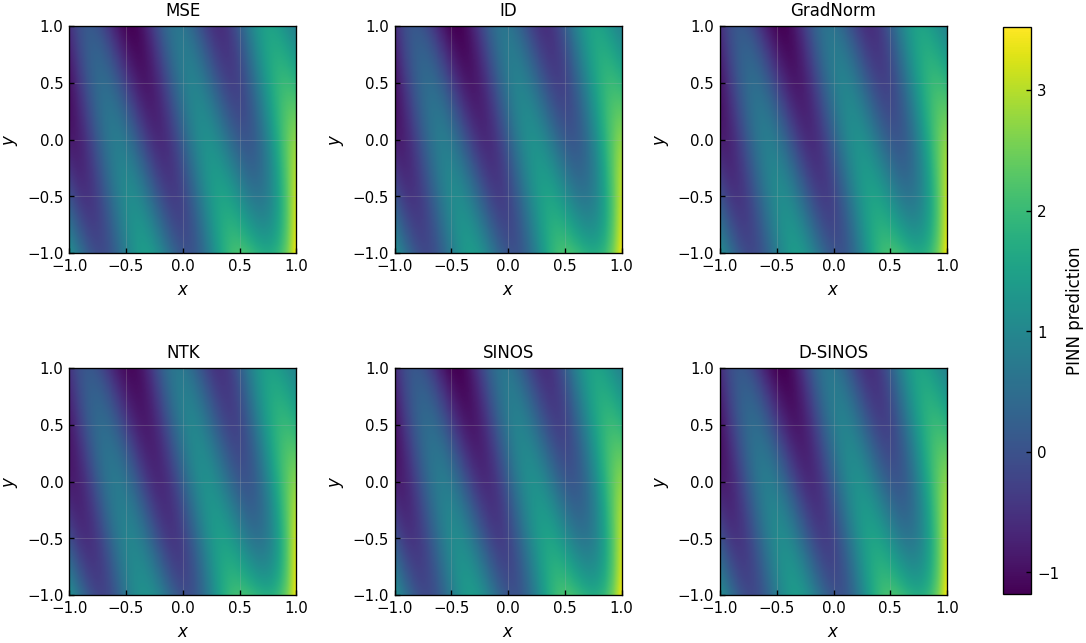

In [126]:
# --- PINN prediction plots ---

vmin = min(arr.min() for arr in best_predictions.values())
vmax = max(arr.max() for arr in best_predictions.values())

fig, axes = plt.subplots(
    2, 3,
    figsize=(9.2, 5.7),
    constrained_layout=True,
)

im = None

for ax, method in zip(axes.flat, method_order):
    im = ax.imshow(
        best_predictions[method].T,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(method)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="PINN prediction",
)

fig.savefig(
    RESULT_DIR / f"best_pinn_prediction_{N_REPS}reps.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()

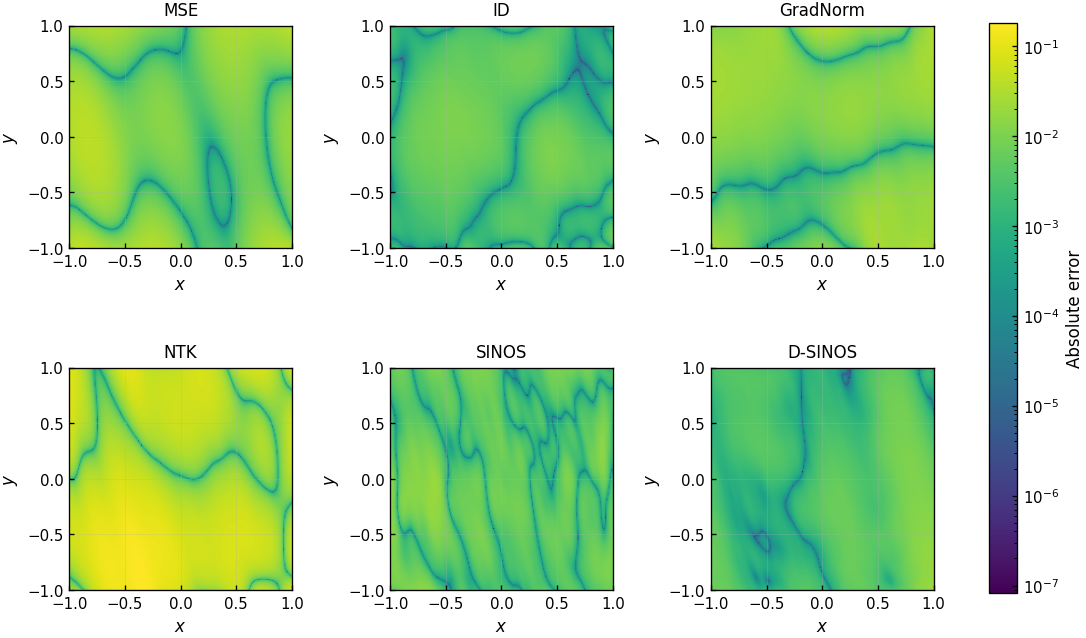

In [127]:
# --- Absolute error plots ---

eps = 1e-14

vmax = max(arr.max() for arr in best_abs_errors.values())

positive_values = np.concatenate(
    [
        arr[arr > eps].ravel()
        for arr in best_abs_errors.values()
        if np.any(arr > eps)
    ]
)

vmin = max(eps, positive_values.min()) if positive_values.size else eps
vmax = max(vmax, 10.0 * vmin)

fig, axes = plt.subplots(
    2, 3,
    figsize=(9.2, 5.7),
    constrained_layout=True,
)

im = None

for ax, method in zip(axes.flat, method_order):
    im = ax.imshow(
        np.maximum(best_abs_errors[method].T, eps),
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="equal",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )

    ax.set_title(method)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    label="Absolute error",
)

fig.savefig(
    RESULT_DIR / f"best_absolute_error_{N_REPS}reps.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600,
)

plt.show()

In [128]:
# --- Mean history plots ---

def mean_history(metric):
    df = hist.sort_values(["method", "rep", "adam_step"]).copy()

    df[metric] = df.groupby(["method", "rep"], observed=True)[metric].cummin()

    return (
        df.groupby(["method", "adam_step"], observed=True)[metric]
        .mean()
        .reset_index()
    )


def plot_mean_history(metric, ylabel, filename):
    agg = mean_history(metric)

    fig, ax = plt.subplots(figsize=(4, 3))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, method in enumerate(method_order):
        df = agg[agg["method"] == method].sort_values("adam_step")
        color = colors[i % len(colors)]

        ax.plot(
            df["adam_step"],
            df[metric],
            color=color,
            linestyle="-",
            label=method,
        )

    ax.set_xscale("symlog", linthresh=1.0, linscale=0.5)
    ax.set_yscale("log")
    ax.set_xlim(left=0, right=MAX_STEPS)

    ax.set_xlabel("Adam step")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(
        ncol=1,
        frameon=True,
        handlelength=1.8,
        columnspacing=0.8,
        labelspacing=0.3,
    )

    plt.tight_layout()
    fig.savefig(
        RESULT_DIR / filename,
        format="pdf",
        bbox_inches="tight",
        dpi=600,
    )
    plt.show()


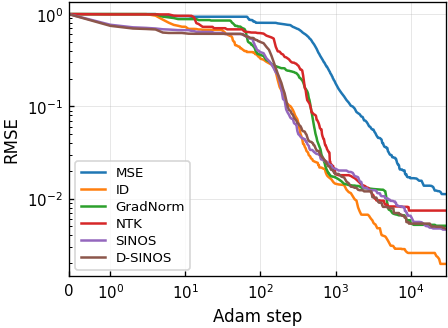

In [129]:
# --- Plot mean RMSE history ---

plot_mean_history(
    "rmse",
    "RMSE",
    f"rmse_history_mean_{N_REPS}reps.pdf",
)

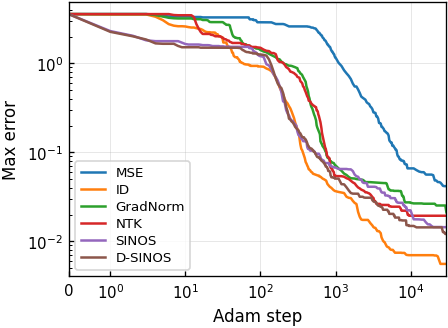

In [130]:
# --- Plot mean maximum error history ---

plot_mean_history(
    "max_error",
    "Max error",
    f"max_error_history_mean_{N_REPS}reps.pdf",
)